In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm


In [73]:
import pandas as pd

# Load the Excel file
df = pd.read_excel("FINALS ICT.xlsx", sheet_name="Sheet1")
print("Total rows loaded:", len(df))
pd.set_option('display.max_rows', None)
df


Total rows loaded: 120


,NO.,COUNTRY,"GDP (2020, Billion USD)",ESTIMATED NUMBER OF MINING OPERATIONS (2020),Unnamed: 4
0,1,China,14720.00,10000,Largest coal producer; widespread mining acros...
1,2,India,2660.00,1319,Based on Ministry of Mines 2020 data.
2,3,Indonesia,1060.00,2000,Dominated by coal and nickel mines.
3,4,Japan,5060.00,100,"Limited to limestone, copper, and some rare ea..."
4,5,South Korea,1640.00,200,Mostly small-scale mineral operations; focuses...
5,6,Russia (Asian part),1480.00,3000,"Siberia hosts extensive mining; large copper, ..."
6,7,Saudi Arabia,700.12,350,Expanding non-oil mineral sector.
7,8,Turkey,719.96,900,"Active in coal, gold, and industrial minerals."
8,9,Iran,203.47,500,"Rich in copper, iron, and zinc."
9,10,Thailand,501.64,300,Tin and industrial minerals are common.


In [74]:
import pandas as pd

# Drop unnecessary columns
df_cleaned = df.drop(columns=["NO.", "Unnamed: 4"])
print("Missing values per column:")
print(df_cleaned.isnull().sum())
print("\nTotal entries after cleaning:", len(df_cleaned))
pd.set_option('display.max_rows', None)
df_cleaned


Missing values per column:
COUNTRY                                         0
GDP (2020, Billion USD)                         0
ESTIMATED NUMBER OF MINING OPERATIONS (2020)    0
dtype: int64

Total entries after cleaning: 120


,COUNTRY,"GDP (2020, Billion USD)",ESTIMATED NUMBER OF MINING OPERATIONS (2020)
0,China,14720.00,10000
1,India,2660.00,1319
2,Indonesia,1060.00,2000
3,Japan,5060.00,100
4,South Korea,1640.00,200
5,Russia (Asian part),1480.00,3000
6,Saudi Arabia,700.12,350
7,Turkey,719.96,900
8,Iran,203.47,500
9,Thailand,501.64,300


In [8]:
# Get numerical arrays
gdp = df_cleaned["GDP (2020, Billion USD)"].values
mining_ops = df_cleaned["ESTIMATED NUMBER OF MINING OPERATIONS (2020)"].values

# Perform 5 NumPy operations
print("Mean GDP:", np.mean(gdp))
print("Median Mining Ops:", np.median(mining_ops))
print("Standard Deviation of GDP:", np.std(gdp))
print("Max Mining Ops:", np.max(mining_ops))
print("Min Mining Ops:", np.min(mining_ops))


Mean GDP: 674.3665833333332
Median Mining Ops: 150.0
Standard Deviation of GDP: 2396.338049767636
Max Mining Ops: 12400
Min Mining Ops: 0


In [54]:
# Calculate correlation
correlation, p_value = stats.pearsonr(gdp, mining_ops)
print("Pearson Correlation Coefficient:", correlation)
print("p-value:", p_value)


Pearson Correlation Coefficient: 0.9163831784997559
p-value: 9.640470025848131e-49


In [72]:
import statsmodels.api as sm

# Define variables with correct column names
gdp = df_cleaned["GDP (2020, Billion USD)"]
mining_ops = df_cleaned["ESTIMATED NUMBER OF MINING OPERATIONS (2020)"]

# OLS regression model
X = sm.add_constant(gdp)
model = sm.OLS(mining_ops, X).fit()
print(model.summary())


                                         OLS Regression Results                                         
Dep. Variable:     ESTIMATED NUMBER OF MINING OPERATIONS (2020)   R-squared:                       0.840
Model:                                                      OLS   Adj. R-squared:                  0.838
Method:                                           Least Squares   F-statistic:                     618.4
Date:                                          Tue, 20 May 2025   Prob (F-statistic):           9.64e-49
Time:                                                  16:16:07   Log-Likelihood:                -940.69
No. Observations:                                           120   AIC:                             1885.
Df Residuals:                                               118   BIC:                             1891.
Df Model:                                                     1                                         
Covariance Type:                                      n

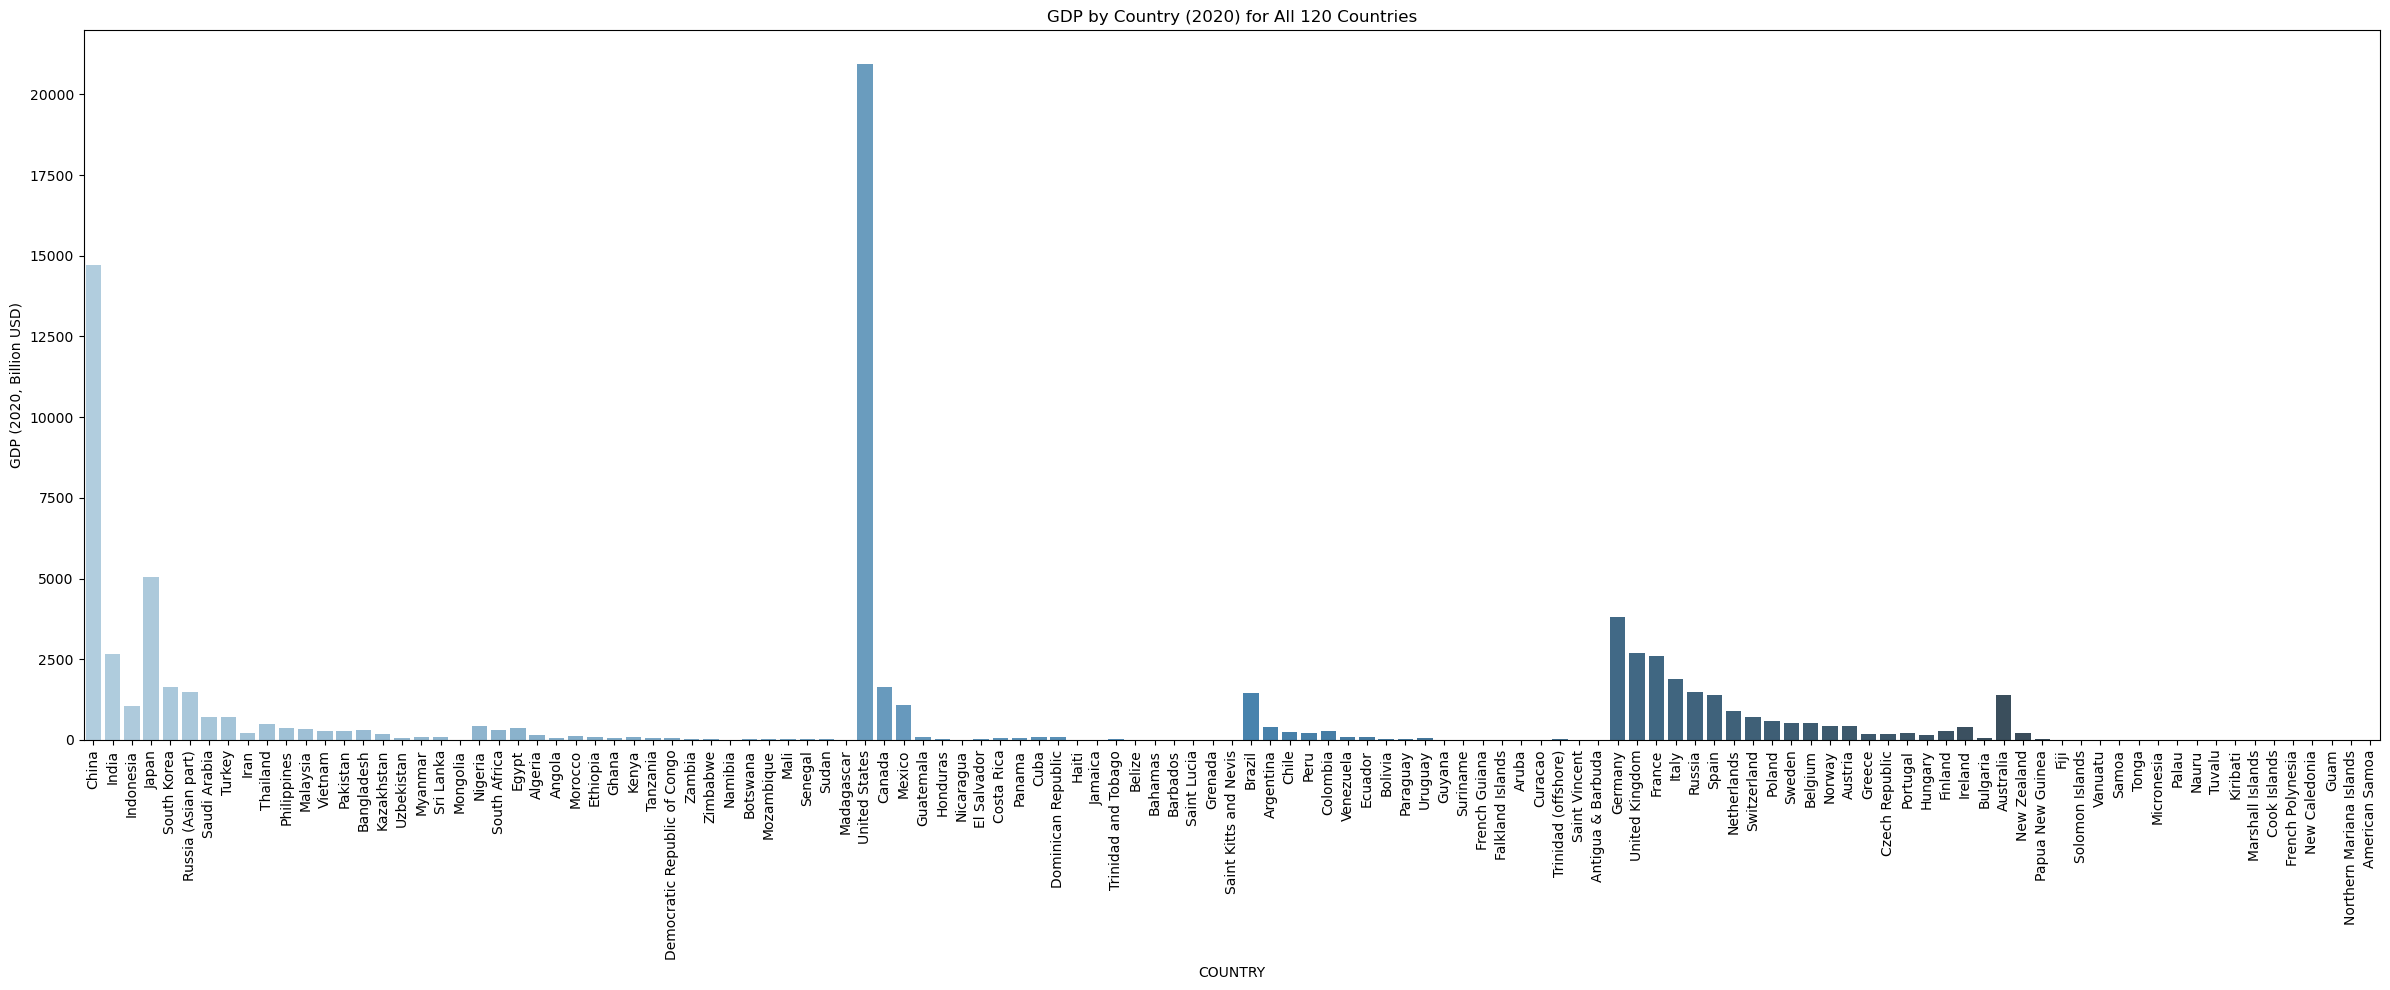

In [4]:
# Visualization 1 - Bar Plot of All Countries' GDP
plt.figure(figsize=(24, 10)) 
sns.barplot(
    data=df,  
    x="COUNTRY",
    y="GDP (2020, Billion USD)",
    hue="COUNTRY",
    legend=False,
    palette="Blues_d"
)
plt.title("GDP by Country (2020) for All 120 Countries")
plt.xticks(rotation=90)  
plt.tight_layout()
plt.show()


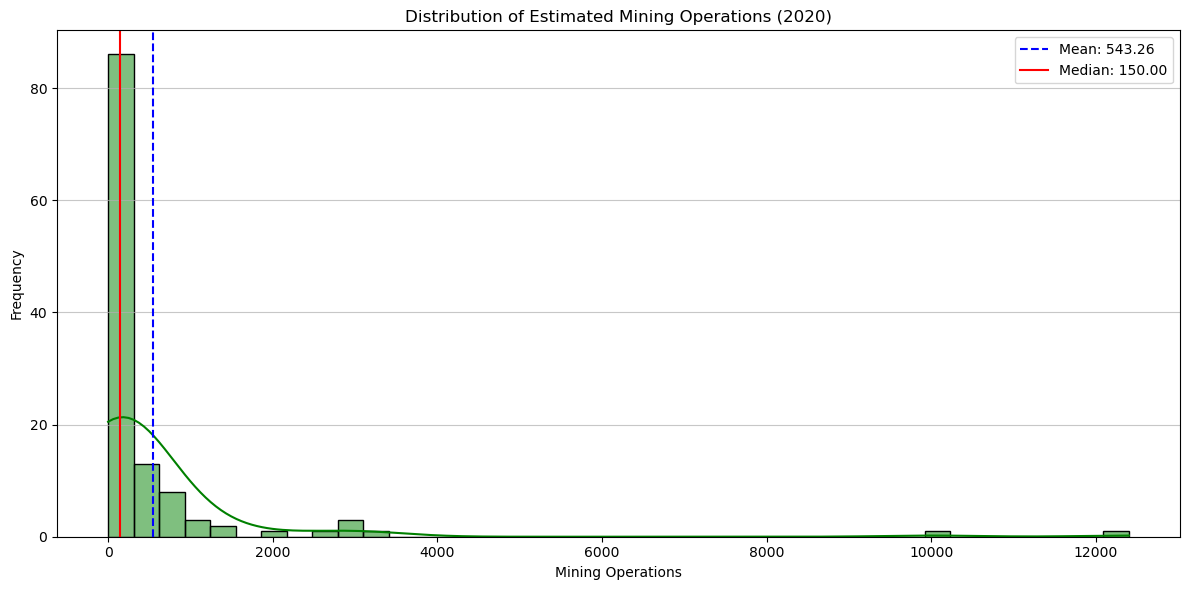

In [76]:
# Visualization 2 - Histogram of Mining Operations
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6)) 
sns.histplot(mining_ops, bins=40, kde=True, color="green")
mean_val = np.mean(mining_ops)
median_val = np.median(mining_ops)
plt.axvline(mean_val, color='blue', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='red', linestyle='-', label=f'Median: {median_val:.2f}')
plt.grid(axis='y', alpha=0.7)
plt.title("Distribution of Estimated Mining Operations (2020)")
plt.xlabel("Mining Operations")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


['COUNTRY', 'GDP (2020, Billion USD)', 'ESTIMATED NUMBER OF MINING OPERATIONS (2020)']


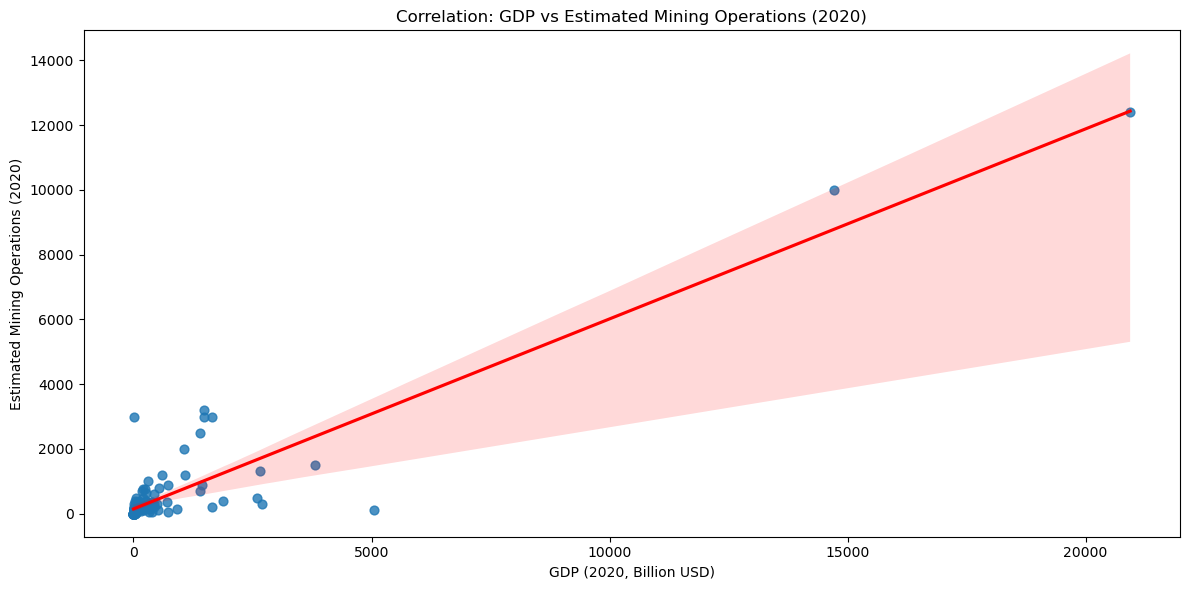

In [78]:
# Visualization of Correlation Plot with Regression Line
print(df_cleaned.columns.tolist())

plt.figure(figsize=(12, 6))

sns.regplot(
    x=df_cleaned["GDP (2020, Billion USD)"],
    y=df_cleaned["ESTIMATED NUMBER OF MINING OPERATIONS (2020)"],
    ci=95,
    scatter_kws={'s': 40},
    line_kws={"color": "red"}
)

plt.title("Correlation: GDP vs Estimated Mining Operations (2020)")
plt.xlabel("GDP (2020, Billion USD)")
plt.ylabel("Estimated Mining Operations (2020)")
plt.tight_layout()
plt.show()


Number of data points after cleaning: 120


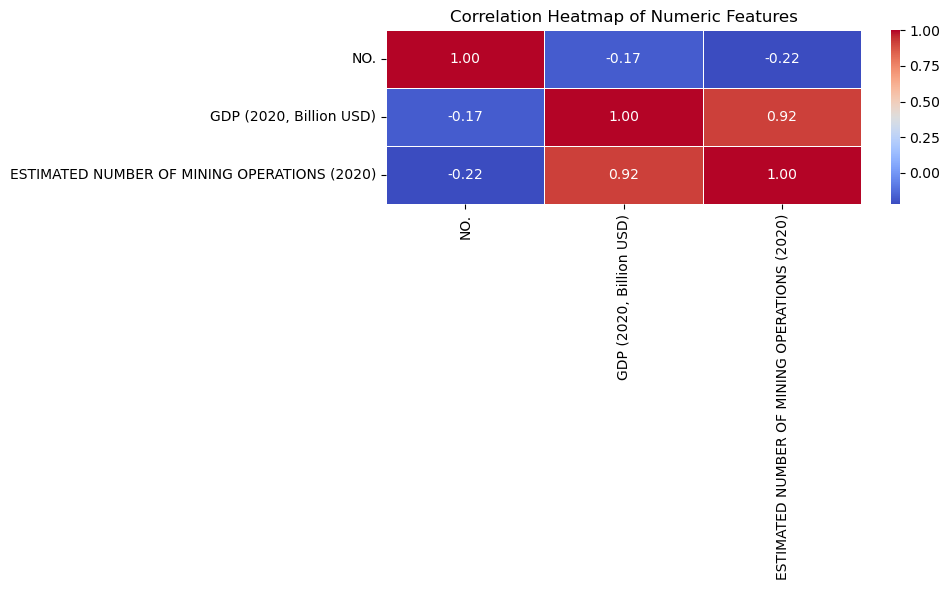

In [6]:
# Correlation heatmap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("FINALS ICT.xlsx", sheet_name="Sheet1")
df_cleaned = df.dropna()
print("Number of data points after cleaning:", len(df_cleaned))
correlation_matrix = df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


### Final Correlation Interpretation

The Pearson correlation coefficient between GDP and the number of mining operations is **0.916**, which indicates a **very strong positive correlation**. This means that countries with higher GDPs tend to have significantly more mining operations, and this relationship is consistent across the dataset.

The **p-value is extremely small (9.64 × 10⁻⁴⁹)**, which is far below the standard significance level of 0.05. This means the correlation is **statistically significant** – the likelihood that this result is due to random chance is virtually zero.

In conclusion, there is a **very strong and statistically significant positive correlation** between a country's economic size (GDP) and its mining activity, based on the data from 2020.
